# Triplex PCR Assay Design for Mycobacterium tuberculosis complex (MTBC) and Mycobacterium avium complex (MAC)

This notebook walks through the full computational workflow for designing a triplex endpoint PCR assay that distinguishes Mycobacterium tuberculosis complex (MTBC) from the Mycobacterium avium complex (MAC). The assay uses IS6110 as a primary MTBC marker, a senX3-regX3-derived fragment as a secondary MTBC marker, and IS1245 as the MAC-associated marker.

IS6110 is included for high analytical sensitivity, senX3-regX3 or rpoB for secondary MTBC confirmation, and IS1245 for MAC-oriented differentiation. Because prior studies have shown that IS6110 may yield specificity problems depending on the amplified region, and that IS1245-related assumptions should be validated against near-neighbor NTM, this notebook includes explicit steps for reference panel design and in silico specificity screening.

The goal is to move cleanly from curated sequence inputs, through singleplex primer design and multiplex compatibility checks, to a final set of primers with documented in silico specificity.

The cell below imports the necessary Python libraries needed for this project

In [1]:
from pathlib import Path
import subprocess
import pandas as pd
import numpy as np
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
import primer3
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

## Step 1. Defining Project Directories

All inputs and outputs for this assay live in a fixed local folder layout. Defining these paths in one place keeps the notebook reproducible and makes it clear where target sequences, comparison panels, and design outputs are stored.

The printed paths below are a quick check that the notebook is pointing at the intended `data/raw` and `results` folders on disk.

In [2]:
BASE = Path("..").resolve()
DATA = BASE / "data"
RAW = DATA / "raw"

TARGET_DIR = RAW / "targets"
MTBC_PANEL_DIR = RAW / "panel_mtbc"
MAC_PANEL_DIR = RAW / "panel_mac"
OFFTARGET_DIR = RAW / "panel_offtargets"

RESULTS = BASE / "results"

for p in [
    TARGET_DIR,
    MTBC_PANEL_DIR,
    MAC_PANEL_DIR,
    OFFTARGET_DIR,
    RESULTS / "alignments",
    RESULTS / "primer_candidates",
    RESULTS / "gel_simulation",
    RESULTS / "blast",
    RESULTS / "screening",
]:
    p.mkdir(parents=True, exist_ok=True)

print("Base directory:", BASE)
print("Target directory:", TARGET_DIR)
print("MTBC panel directory:", MTBC_PANEL_DIR)
print("MAC panel directory:", MAC_PANEL_DIR)
print("Off-target directory:", OFFTARGET_DIR)
print("Results directory:", RESULTS)

Base directory: /home/solotan
Target directory: /home/solotan/data/raw/targets
MTBC panel directory: /home/solotan/data/raw/panel_mtbc
MAC panel directory: /home/solotan/data/raw/panel_mac
Off-target directory: /home/solotan/data/raw/panel_offtargets
Results directory: /home/solotan/results


## Step 2. Verifying Essential FASTA Files

Before doing any design work, it’s worth confirming that all essential inputs are actually present. This includes the three assay targets and the small comparison panel for MTBC, MAC, and selected off-target mycobacteria.

In [3]:
required_target_files = {
    "IS6110_X17348": TARGET_DIR / "IS6110_X17348.fasta",
    "IS1245_L33879": TARGET_DIR / "IS1245_L33879.fasta",
    "MTBC_SECONDARY_senX3regX3": TARGET_DIR / "MTBC_SECONDARY_senX3regX3.fasta",
}

required_panel_files = {
    "Mycobacterium_tuberculosis_H37Rv": MTBC_PANEL_DIR / "Mycobacterium_tuberculosis_H37Rv.fasta",
    "Mycobacterium_bovis": MTBC_PANEL_DIR / "Mycobacterium_bovis.fasta",
    "Mycobacterium_avium": MAC_PANEL_DIR / "Mycobacterium_avium.fasta",
    "Mycobacterium_intracellulare": MAC_PANEL_DIR / "Mycobacterium_intracellulare.fasta",
    "Mycobacterium_kansasii": OFFTARGET_DIR / "Mycobacterium_kansasii.fasta",
    "Mycobacteroides_abscessus": OFFTARGET_DIR / "Mycobacteroides_abscessus.fasta",
    "Mycobacterium_fortuitum": OFFTARGET_DIR / "Mycobacterium_fortuitum.fasta",
    "Mycobacterium_gordonae": OFFTARGET_DIR / "Mycobacterium_gordonae.fasta",
}

for name, path in required_target_files.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing required target FASTA: {path}")

for name, path in required_panel_files.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing required panel FASTA: {path}")

print("All required target and panel FASTA files were found.\n")

for name, path in required_target_files.items():
    rec = next(SeqIO.parse(str(path), "fasta-pearson"))
    print(f"{name}: {rec.id} | {len(rec.seq)} bp")

All required target and panel FASTA files were found.

IS6110_X17348: X17348.1 | 1360 bp
IS1245_L33879: L33879.1 | 1414 bp
MTBC_SECONDARY_senX3regX3: Y13628.1 | 2187 bp


## Step 3. Parsing and Loading Sequences

The next step is to load each directory of FASTA files into Biopython sequence records from the confirmed file path.

In [4]:
def load_fasta_dir(directory: Path):
    records = []
    for fasta in sorted(directory.glob("*.fa*")):
        with open(fasta, "r", encoding="utf-8-sig") as handle:
            records.extend(list(SeqIO.parse(handle, "fasta-pearson")))
    return records

target_records = load_fasta_dir(TARGET_DIR)
mtbc_records = load_fasta_dir(MTBC_PANEL_DIR)
mac_records = load_fasta_dir(MAC_PANEL_DIR)
offtarget_records = load_fasta_dir(OFFTARGET_DIR)

print("Target records:", len(target_records))
print("MTBC panel records:", len(mtbc_records))
print("MAC panel records:", len(mac_records))
print("Off-target panel records:", len(offtarget_records))

Target records: 3
MTBC panel records: 2
MAC panel records: 2
Off-target panel records: 4


The simple counts printed above (targets, MTBC panel, MAC panel, off-target panel) are a sanity check that the panel composition matches what the assay was designed around.

## Step 4. Documenting the Sequence Manifest

A manifest of all local inputs is exported to preserve a transparent record of the analysis panel. This is useful for later validation because it documents exactly which sequences were included in the design-stage workflow.

In [5]:
panel_manifest = pd.DataFrame(
    [{"Input group": "target", "Sequence record": rec.id, "length (bp)": len(rec.seq)} for rec in target_records]
    + [{"Input group": "panel_mtbc", "Sequence record": rec.id, "length (bp)": len(rec.seq)} for rec in mtbc_records]
    + [{"Input group": "panel_mac", "Sequence record": rec.id, "length (bp)": len(rec.seq)} for rec in mac_records]
    + [{"Input group": "panel_offtargets", "Sequence record": rec.id, "length (bp)": len(rec.seq)} for rec in offtarget_records]
)

panel_manifest_path = RESULTS / "screening" / "In_silico_panel_manifest.csv"
panel_manifest.to_csv(panel_manifest_path, index=False)
panel_manifest

,Input group,Sequence record,length (bp)
0,target,L33879.1,1414
1,target,X17348.1,1360
2,target,Y13628.1,2187
3,panel_mtbc,CP002095.1,4350386
4,panel_mtbc,AP018036.1,4413362
5,panel_mac,AP042357.1,5355463
6,panel_mac,CP023146.1,5432063
7,panel_offtargets,CP011269.1,6254616
8,panel_offtargets,LKTM01000001.1,455117
9,panel_offtargets,CP089216.1,6436818


This manifest is the notebook’s record of what went into the analysis. It captures both the assay targets and the local panel used later for the exact-match screen.

In [6]:
for rec in target_records:
    print("filename placeholder", "->", rec.id, "|", rec.description)

filename placeholder -> L33879.1 | L33879.1 Mycobacterium avium insertion sequence IS1245 transposase gene, complete cds
filename placeholder -> X17348.1 | X17348.1 Mycobacterium tuberculosis IS6110 IS-like element
filename placeholder -> Y13628.1 | Y13628.1 Mycobacterium tuberculosis senX3, regX3 genes and 3 putative ORF's


## Step 5. Summarizing the assay targets

The three loci the assay is built around is shown below before moving into primer design. This keeps the biological logic of the triplex clear from the start: one target provides the primary MTBC signal, one provides secondary MTBC support, and one represents the MAC arm of the assay.

In [7]:
def target_classification(record_id: str) -> str:
    if record_id.startswith("X17348"):
        return "Primary MTBC target"
    elif record_id.startswith("Y13628"):
        return "Secondary MTBC target"
    elif record_id.startswith("L33879"):
        return "MAC target"
    else:
        return "Unassigned target"

classification_table = pd.DataFrame(
    [{"Target record": rec.id,
      "Target description": rec.description,
      "Assay role": target_classification(rec.id),
      "Length (bp)": len(rec.seq)}
     for rec in target_records]
)

classification_table

,Target record,Target description,Assay role,Length (bp)
0,L33879.1,L33879.1 Mycobacterium avium insertion sequenc...,MAC target,1414
1,X17348.1,X17348.1 Mycobacterium tuberculosis IS6110 IS-...,Primary MTBC target,1360
2,Y13628.1,"Y13628.1 Mycobacterium tuberculosis senX3, reg...",Secondary MTBC target,2187


This table defines the three biological targets that anchor the assay design. Everything that follows in the notebook is built around these three records and their corresponding assay roles.

## (Optional) Combining the assay targets into a single reference file

The three target loci have been identified clearly; they are now gathered into one FASTA file for reference and record-keeping. This does not determine the final scoring, but it keeps the assay-defining sequences together in a form that is easy to inspect later (if need be).

In [8]:
def write_records(records, outfile: Path):
    SeqIO.write(records, str(outfile), "fasta")

combined_targets = RESULTS / "alignments" / "triplex_targets_combined.fasta"
aligned_targets = RESULTS / "alignments" / "aligned_triplex_targets_combined.fasta"

write_records(target_records, combined_targets)

cmd = f"mafft --auto {combined_targets} > {aligned_targets}"
subprocess.run(cmd, shell=True, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

print("Combined target FASTA written to:", combined_targets)
print("Aligned target FASTA written to:", aligned_targets)

Combined target FASTA written to: /home/solotan/results/alignments/triplex_targets_combined.fasta
Aligned target FASTA written to: /home/solotan/results/alignments/aligned_triplex_targets_combined.fasta


The combined target FASTA is mainly a supporting project artifact.

## Step 6. Primer3 settings for single‑target design

Primer design for this assay is done with Primer3, using settings tuned for products in the 120–550 bp range and primer melting temperatures around 60°C. These ranges are chosen to keep band sizes readable on standard agarose gels and to make multiplex annealing conditions achievable.

This section defines the Primer3 parameters and runs single‑target primer design separately for each locus before any multiplex constraints are considered.

In [9]:
design_windows = {
    "Primary MTBC target": (120, 180),
    "Secondary MTBC target": (260, 340),
    "MAC target": (420, 550),
}

def design_primers(sequence, seq_id, product_size_range, num_return=10):
    seq = str(sequence).upper().replace("-", "")
    result = primer3.bindings.design_primers(
        {
            "SEQUENCE_ID": seq_id,
            "SEQUENCE_TEMPLATE": seq,
        },
        {
            "PRIMER_OPT_SIZE": 20,
            "PRIMER_MIN_SIZE": 18,
            "PRIMER_MAX_SIZE": 25,
            "PRIMER_OPT_TM": 60.0,
            "PRIMER_MIN_TM": 58.0,
            "PRIMER_MAX_TM": 63.0,
            "PRIMER_MIN_GC": 40.0,
            "PRIMER_MAX_GC": 65.0,
            "PRIMER_PRODUCT_SIZE_RANGE": [product_size_range],
            "PRIMER_NUM_RETURN": num_return,
        }
    )
    return result

The product size windows are defined separately for each assay target so that the final triplex is more likely to yield clearly separated bands on an endpoint agarose gel. Primer melting temperatures are kept in a narrow but practical range around 60°C to support a shared multiplex annealing condition, while primer length and GC-content constraints are set within conventional PCR design bounds.

## Step 7. Single-target Primer Design

Candidate primer design is executed independently for each target sequence. This preserves assay-specific product-size logic at the design stage while allowing all resulting candidates to be compared later for multiplex compatibility and early specificity screening.

In [10]:
primer3_design_results = {}

for record in target_records:
    assay_role = target_classification(record.id)
    print(f"{record.id} classified as {assay_role}")

    if assay_role == "Unassigned target":
        continue

    result = design_primers(
        sequence=record.seq,
        seq_id=record.id,
        product_size_range=design_windows[assay_role],
        num_return=10,
    )
    n_pairs = result.get("PRIMER_PAIR_NUM_RETURNED", 0)
    print(f"  Primer3 returned {n_pairs} pairs")

    if n_pairs > 0:
        primer3_design_results[record.id] = {
            "Assay role": assay_role,
            "Primer3 result": result,
        }

print("\nPrimer design completed for:")
for assay_name, payload in primer3_design_results.items():
    print(f"  {assay_name} -> {payload['Assay role']}")

L33879.1 classified as MAC target
  Primer3 returned 10 pairs
X17348.1 classified as Primary MTBC target
  Primer3 returned 10 pairs
Y13628.1 classified as Secondary MTBC target
  Primer3 returned 10 pairs

Primer design completed for:
  L33879.1 -> MAC target
  X17348.1 -> Primary MTBC target
  Y13628.1 -> Secondary MTBC target


## Step 8. Parsing the Single-target Primer3 Design Result

Primer3 output must be normalized into a structured table before candidate evaluation. This step converts the nested output into a tabular record of primer sequence, melting temperature, GC content, product size, and pair penalty, making the candidate-selection process transparent and auditable.

In [11]:
def parse_primer3_result(primer3_result, assay_target_record, assay_role):
    primer_rows = []
    n_pairs = primer3_result.get("PRIMER_PAIR_NUM_RETURNED", 0)

    for pair_index in range(n_pairs):
        primer_rows.append({
            "Assay target record": assay_target_record,
            "Assay role": assay_role,
            "Pair index": pair_index,
            "Forward primer": primer3_result.get(f"PRIMER_LEFT_{pair_index}_SEQUENCE"),
            "Reverse primer": primer3_result.get(f"PRIMER_RIGHT_{pair_index}_SEQUENCE"),
            "Forward Tm": primer3_result.get(f"PRIMER_LEFT_{pair_index}_TM"),
            "Reverse Tm": primer3_result.get(f"PRIMER_RIGHT_{pair_index}_TM"),
            "Forward GC (%)": primer3_result.get(f"PRIMER_LEFT_{pair_index}_GC_PERCENT"),
            "Reverse GC (%)": primer3_result.get(f"PRIMER_RIGHT_{pair_index}_GC_PERCENT"),
            "Expected product (bp)": primer3_result.get(f"PRIMER_PAIR_{pair_index}_PRODUCT_SIZE"),
            "Pair penalty": primer3_result.get(f"PRIMER_PAIR_{pair_index}_PENALTY"),
        })

    return pd.DataFrame(primer_rows)


single_target_candidate_tables = []

for assay_target_record, payload in primer3_design_results.items():
    candidate_table = parse_primer3_result(
        payload["Primer3 result"],
        assay_target_record,
        payload["Assay role"]
    )
    print(assay_target_record, payload["Assay role"], "->", len(candidate_table), "rows")
    single_target_candidate_tables.append(candidate_table)


L33879.1 MAC target -> 10 rows
X17348.1 Primary MTBC target -> 10 rows
Y13628.1 Secondary MTBC target -> 10 rows


## Step 9. Ranking the Single-target Candidates

The block below consolidates the primer candidates into a single DataFrame and calculates a custom `Tm balance` (the absolute difference between Forward and Reverse $T_m$). This difference is added to the base `primer3` penalty to create a `Within-target composite score`. The candidates are then grouped by their target (`Assay role`) and sorted in ascending order. The pairs with the lowest penalty scores—representing the most thermodynamically balanced primers—are elevated to the top of the dataset.

In [12]:
single_target_candidates = pd.concat(single_target_candidate_tables, ignore_index=True)

single_target_candidates["Tm balance"] = (
    single_target_candidates["Forward Tm"] - single_target_candidates["Reverse Tm"]
).abs()

single_target_candidates["Within-target composite score"] = (
    single_target_candidates["Pair penalty"] + single_target_candidates["Tm balance"]
)

ranked_single_target_candidates = (
    single_target_candidates
    .sort_values(
        ["Assay role", "Within-target composite score", "Pair penalty", "Pair index"]
    )
    .reset_index(drop=True)
)

raw_candidate_path = RESULTS / "primer_candidates" / "single_target_candidates_raw.csv"
ranked_candidate_path = RESULTS / "primer_candidates" / "single_target_candidates_ranked.csv"

single_target_candidates.to_csv(raw_candidate_path, index=False)
ranked_single_target_candidates.to_csv(ranked_candidate_path, index=False)

print("Raw candidates shape:", single_target_candidates.shape)
print("Ranked candidates shape:", ranked_single_target_candidates.shape)
print(ranked_single_target_candidates["Assay role"].value_counts())

ranked_single_target_candidates

Raw candidates shape: (30, 13)
Ranked candidates shape: (30, 13)
Assay role
MAC target               10
Primary MTBC target      10
Secondary MTBC target    10
Name: count, dtype: int64


,Assay target record,Assay role,Pair index,Forward primer,Reverse primer,Forward Tm,Reverse Tm,Forward GC (%),Reverse GC (%),Expected product (bp),Pair penalty,Tm balance,Within-target composite score
0,L33879.1,MAC target,0,GCGTGAGTCTCTGTGGTGAA,GGTGTCGAGGTCTTTGCAGA,59.967870,59.966496,55.0,55.0,489,0.065634,0.001374,0.067008
1,L33879.1,MAC target,2,TCTGCAAAGACCTCGACACC,CATGGTTTCGACCTTGGGGA,59.966496,59.962410,55.0,55.0,515,0.071094,0.004086,0.075180
2,L33879.1,MAC target,3,GGTGAATCATCGGGTGGTGT,GCGGCGTTTGATTTCCTTGT,60.035439,60.039527,55.0,50.0,526,0.074966,0.004088,0.079054
3,L33879.1,MAC target,4,GGTGAATCATCGGGTGGTGT,GTGCGGCGTTTGATTTCCTT,60.035439,60.039527,55.0,50.0,528,0.074966,0.004088,0.079054
4,L33879.1,MAC target,5,GGTGAATCATCGGGTGGTGT,TGCGGCGTTTGATTTCCTTG,60.035439,60.039617,55.0,50.0,527,0.075056,0.004179,0.079235
5,L33879.1,MAC target,1,GCGTGAGTCTCTGTGGTGAA,CAGTGCCTTGACCAGATCGT,59.967870,60.036952,55.0,55.0,429,0.069082,0.069082,0.138164
6,L33879.1,MAC target,7,CTGACGTAAGAGGGCCATCC,GGTGTCGAGGTCTTTGCAGA,59.894961,59.966496,60.0,55.0,509,0.138543,0.071535,0.210078
7,L33879.1,MAC target,8,CCTGACGTAAGAGGGCCATC,GGTGTCGAGGTCTTTGCAGA,59.894961,59.966496,60.0,55.0,510,0.138543,0.071535,0.210078
8,L33879.1,MAC target,6,CCGGAGTCCAACTGGTCATC,GGTTTCGGCACTTTGGTCAC,60.108138,59.969765,60.0,55.0,533,0.138373,0.138373,0.276746
9,L33879.1,MAC target,9,ATTTTTCCCGGCGTTGTTGG,GATGACCAGTTGGACTCCGG,59.967185,60.108138,50.0,60.0,436,0.140952,0.140952,0.281905


## Step 10. Isolating Top Candidates for Multiplex Integration

The completely ranked dataset above is filtered by `Assay role` and the top 5 performing primer pairs are extracted for the Primary MTBC, Secondary MTBC, and MAC targets. The selected candidates and their key thermodynamic properties are then displayed for visual confirmation before they are passed into the multiplexing step.

In [13]:
top5_primary = (
    ranked_single_target_candidates[
        ranked_single_target_candidates["Assay role"] == "Primary MTBC target"
    ]
    .head(5)
    .reset_index(drop=True)
)

top5_secondary = (
    ranked_single_target_candidates[
        ranked_single_target_candidates["Assay role"] == "Secondary MTBC target"
    ]
    .head(5)
    .reset_index(drop=True)
)

top5_mac = (
    ranked_single_target_candidates[
        ranked_single_target_candidates["Assay role"] == "MAC target"
    ]
    .head(5)
    .reset_index(drop=True)
)

print("Top 5 Primary MTBC target candidates")
display(
    top5_primary[
        [
            "Assay target record",
            "Pair index",
            "Forward primer",
            "Reverse primer",
            "Forward Tm",
            "Reverse Tm",
            "Expected product (bp)",
            "Pair penalty",
            "Within-target composite score",
        ]
    ]
)

print("Top 5 Secondary MTBC target candidates")
display(
    top5_secondary[
        [
            "Assay target record",
            "Pair index",
            "Forward primer",
            "Reverse primer",
            "Forward Tm",
            "Reverse Tm",
            "Expected product (bp)",
            "Pair penalty",
            "Within-target composite score",
        ]
    ]
)

print("Top 5 MAC target candidates")
display(
    top5_mac[
        [
            "Assay target record",
            "Pair index",
            "Forward primer",
            "Reverse primer",
            "Forward Tm",
            "Reverse Tm",
            "Expected product (bp)",
            "Pair penalty",
            "Within-target composite score",
        ]
    ]
)

Top 5 Primary MTBC target candidates


,Assay target record,Pair index,Forward primer,Reverse primer,Forward Tm,Reverse Tm,Expected product (bp),Pair penalty,Within-target composite score
0,X17348.1,1,ACTCAAGGAGCACATCAGCC,AGGCCGAGTTTGGTCATCAG,60.035630,60.036010,138,0.071640,0.072020
1,X17348.1,0,ACTCAAGGAGCACATCAGCC,TTTGGTCATCAGCCGTTCGA,60.035630,59.965802,130,0.069827,0.139655
2,X17348.1,2,GATCGAGCAAGCCATCTGGA,GTCATAGGAGCTTCCGACCG,59.894407,59.969092,166,0.136501,0.211187
3,X17348.1,8,GAGTCGATCTGCACACAGCT,GGCTGATGTGCTCCTTGAGT,60.108898,60.035630,127,0.144528,0.217796
4,X17348.1,9,GTCGAGTCGATCTGCACACA,GGCTGATGTGCTCCTTGAGT,60.109735,60.035630,130,0.145365,0.219470


Top 5 Secondary MTBC target candidates


,Assay target record,Pair index,Forward primer,Reverse primer,Forward Tm,Reverse Tm,Expected product (bp),Pair penalty,Within-target composite score
0,Y13628.1,3,ATCCGGGCTATCAGTGCATG,TAGCCGGGATAGCTCGATCA,59.964119,59.962266,298,0.073614,0.075467
1,Y13628.1,4,TGGTGAAGACGTCGAGTTCG,GGCCTCAATGAGCACCTTCT,60.040692,60.034670,304,0.075363,0.081384
2,Y13628.1,0,ACTGGCAAACCTGGTTTCCA,TGATAGGCCTCGATCAACGC,60.032615,59.967870,324,0.064745,0.129489
3,Y13628.1,1,GGTGGTGAAGACGTCGAGTT,GGCCTCAATGAGCACCTTCT,59.968279,60.034670,306,0.066392,0.132783
4,Y13628.1,2,GCGTTGATCGAGGCCTATCA,CTCCTCATCGCTACGCTCTG,59.967870,60.040514,294,0.072644,0.145288


Top 5 MAC target candidates


,Assay target record,Pair index,Forward primer,Reverse primer,Forward Tm,Reverse Tm,Expected product (bp),Pair penalty,Within-target composite score
0,L33879.1,0,GCGTGAGTCTCTGTGGTGAA,GGTGTCGAGGTCTTTGCAGA,59.967870,59.966496,489,0.065634,0.067008
1,L33879.1,2,TCTGCAAAGACCTCGACACC,CATGGTTTCGACCTTGGGGA,59.966496,59.962410,515,0.071094,0.075180
2,L33879.1,3,GGTGAATCATCGGGTGGTGT,GCGGCGTTTGATTTCCTTGT,60.035439,60.039527,526,0.074966,0.079054
3,L33879.1,4,GGTGAATCATCGGGTGGTGT,GTGCGGCGTTTGATTTCCTT,60.035439,60.039527,528,0.074966,0.079054
4,L33879.1,5,GGTGAATCATCGGGTGGTGT,TGCGGCGTTTGATTTCCTTG,60.035439,60.039617,527,0.075056,0.079235


The generated tables display the top-ranked primer pairs for each target candidate. For each target candidate, the $T_m$ values are tightly maintained around 60°C. The "Expected product (bp)" column indicates the size of the resulting DNA fragment for each pair, which will be vital for the upcoming multiplex size-differentiation checks.

## Step 11. Generating All Triplex Combinations

In multiplex PCR, the best-performing individual primer pairs do not always function well when mixed together due to unpredictable cross-reactivity (primer-dimers) or amplicon size overlaps. Therefore, it cannot be assumed that the #1 pair from each target will form the optimal triplex. To identify the true best combination, every possible mixture of the top singleplex candidates must be mathematically generated and subsequently evaluated as a complete, six-primer system.

In [14]:
triplex_rows = []

for _, primary_row in top5_primary.iterrows():
    for _, secondary_row in top5_secondary.iterrows():
        for _, mac_row in top5_mac.iterrows():
            triplex_rows.append({
                "Primary pair index": primary_row["Pair index"],
                "Secondary pair index": secondary_row["Pair index"],
                "MAC pair index": mac_row["Pair index"],

                "Primary assay target record": primary_row["Assay target record"],
                "Secondary assay target record": secondary_row["Assay target record"],
                "MAC assay target record": mac_row["Assay target record"],

                "Primary forward primer": primary_row["Forward primer"],
                "Primary reverse primer": primary_row["Reverse primer"],
                "Secondary forward primer": secondary_row["Forward primer"],
                "Secondary reverse primer": secondary_row["Reverse primer"],
                "MAC forward primer": mac_row["Forward primer"],
                "MAC reverse primer": mac_row["Reverse primer"],

                "Primary expected product (bp)": primary_row["Expected product (bp)"],
                "Secondary expected product (bp)": secondary_row["Expected product (bp)"],
                "MAC expected product (bp)": mac_row["Expected product (bp)"],

                "Primary within-target composite score": primary_row["Within-target composite score"],
                "Secondary within-target composite score": secondary_row["Within-target composite score"],
                "MAC within-target composite score": mac_row["Within-target composite score"],

                "Primary mean Tm": (primary_row["Forward Tm"] + primary_row["Reverse Tm"]) / 2,
                "Secondary mean Tm": (secondary_row["Forward Tm"] + secondary_row["Reverse Tm"]) / 2,
                "MAC mean Tm": (mac_row["Forward Tm"] + mac_row["Reverse Tm"]) / 2,
            })

triplex_candidates = pd.DataFrame(triplex_rows)

triplex_candidate_path = RESULTS / "primer_candidates" / "triplex_candidate_combinations.csv"
triplex_candidates.to_csv(triplex_candidate_path, index=False)

print("Triplex combinations generated:", len(triplex_candidates))
print("Saved to:", triplex_candidate_path)

triplex_candidates.head()

Triplex combinations generated: 125
Saved to: /home/solotan/results/primer_candidates/triplex_candidate_combinations.csv


,Primary pair index,Secondary pair index,MAC pair index,Primary assay target record,Secondary assay target record,MAC assay target record,Primary forward primer,Primary reverse primer,Secondary forward primer,Secondary reverse primer,...,MAC reverse primer,Primary expected product (bp),Secondary expected product (bp),MAC expected product (bp),Primary within-target composite score,Secondary within-target composite score,MAC within-target composite score,Primary mean Tm,Secondary mean Tm,MAC mean Tm
0,1,3,0,X17348.1,Y13628.1,L33879.1,ACTCAAGGAGCACATCAGCC,AGGCCGAGTTTGGTCATCAG,ATCCGGGCTATCAGTGCATG,TAGCCGGGATAGCTCGATCA,...,GGTGTCGAGGTCTTTGCAGA,138,298,489,0.07202,0.075467,0.067008,60.03582,59.963193,59.967183
1,1,3,2,X17348.1,Y13628.1,L33879.1,ACTCAAGGAGCACATCAGCC,AGGCCGAGTTTGGTCATCAG,ATCCGGGCTATCAGTGCATG,TAGCCGGGATAGCTCGATCA,...,CATGGTTTCGACCTTGGGGA,138,298,515,0.07202,0.075467,0.075180,60.03582,59.963193,59.964453
2,1,3,3,X17348.1,Y13628.1,L33879.1,ACTCAAGGAGCACATCAGCC,AGGCCGAGTTTGGTCATCAG,ATCCGGGCTATCAGTGCATG,TAGCCGGGATAGCTCGATCA,...,GCGGCGTTTGATTTCCTTGT,138,298,526,0.07202,0.075467,0.079054,60.03582,59.963193,60.037483
3,1,3,4,X17348.1,Y13628.1,L33879.1,ACTCAAGGAGCACATCAGCC,AGGCCGAGTTTGGTCATCAG,ATCCGGGCTATCAGTGCATG,TAGCCGGGATAGCTCGATCA,...,GTGCGGCGTTTGATTTCCTT,138,298,528,0.07202,0.075467,0.079054,60.03582,59.963193,60.037483
4,1,3,5,X17348.1,Y13628.1,L33879.1,ACTCAAGGAGCACATCAGCC,AGGCCGAGTTTGGTCATCAG,ATCCGGGCTATCAGTGCATG,TAGCCGGGATAGCTCGATCA,...,TGCGGCGTTTGATTTCCTTG,138,298,527,0.07202,0.075467,0.079235,60.03582,59.963193,60.037528


125 unique triplex combinations are successfully generated. The table above shows each  each row containing the six necessary primers, their expected product sizes, and their individual thermodynamic scores.

## Step 12. Thermodynamic and Band-Gap Evaluation

A successful multiplex assay must overcome two major physical hurdles. First, the primers must not interact with each other; in a 6-primer system, there are 15 potential pairwise interactions that could form primer-dimers, which consume reagents and generate false signals. Second, the resulting PCR amplicons must be easily distinguishable upon gel electrophoresis. If the DNA fragments are too close in size, they will overlap, rendering the assay unreadable.

Each triplex combination is evaluated leveraging the `primer3` engine to calculate the binding thermodynamics ($\Delta G$ and $T_m$) between any two primers. All 15 primer combinations within a triplex set are evaluated to find the worst-case heterodimer penalty. 
Then, the three expected amplicon sizes is evaluated and the `Minimum band gap (bp)` is calculated to ensure distinct gel resolution.
This evaluation is done across all 125 triplex candidates.

In [15]:
def calculate_pairwise_heterodimer(primer_a, primer_b):
    heterodimer = primer3.bindings.calc_heterodimer(primer_a, primer_b)
    return {
        "dg": heterodimer.dg,
        "tm": heterodimer.tm,
        "structure_found": heterodimer.structure_found,
    }


def evaluate_triplex_candidate(row):
    primers = {
        "Primary forward primer": row["Primary forward primer"],
        "Primary reverse primer": row["Primary reverse primer"],
        "Secondary forward primer": row["Secondary forward primer"],
        "Secondary reverse primer": row["Secondary reverse primer"],
        "MAC forward primer": row["MAC forward primer"],
        "MAC reverse primer": row["MAC reverse primer"],
    }

    primer_names = list(primers.keys())
    dimer_results = []

    for i in range(len(primer_names)):
        for j in range(i + 1, len(primer_names)):
            primer_1_name = primer_names[i]
            primer_2_name = primer_names[j]
            dimer_metrics = calculate_pairwise_heterodimer(
                primers[primer_1_name],
                primers[primer_2_name]
            )
            dimer_results.append({
                "Primer 1": primer_1_name,
                "Primer 2": primer_2_name,
                **dimer_metrics,
            })

    dimer_df = pd.DataFrame(dimer_results)

    worst_dg = dimer_df["dg"].min() if not dimer_df.empty else np.nan
    max_dimer_tm = dimer_df["tm"].max() if not dimer_df.empty else np.nan
    n_dimer_structures = int(dimer_df["structure_found"].sum()) if not dimer_df.empty else 0

    product_sizes = sorted([
        row["Primary expected product (bp)"],
        row["Secondary expected product (bp)"],
        row["MAC expected product (bp)"],
    ])
    min_band_gap = min(
        product_sizes[1] - product_sizes[0],
        product_sizes[2] - product_sizes[1],
    )

    return {
        "Worst heterodimer ΔG": worst_dg,
        "Maximum heterodimer Tm": max_dimer_tm,
        "Number of heterodimer structures": n_dimer_structures,
        "Minimum band gap (bp)": min_band_gap,
    }


triplex_evaluation_rows = []

for _, triplex_row in triplex_candidates.iterrows():
    triplex_evaluation_rows.append(evaluate_triplex_candidate(triplex_row))

triplex_evaluation = pd.DataFrame(triplex_evaluation_rows)
triplex_evaluation.head()

,Worst heterodimer ΔG,Maximum heterodimer Tm,Number of heterodimer structures,Minimum band gap (bp)
0,-7980.268602,22.589722,15,160
1,-7980.268602,22.589722,15,160
2,-7980.268602,22.589722,15,160
3,-7980.268602,22.589722,15,160
4,-7980.268602,22.589722,15,160


The table above displays the physical simulation results for the first five triplex combinations. The `Worst heterodimer ΔG` isolates the strongest predicted primer-dimer interaction, while the `Minimum band gap (bp)` confirms the closest distance between any two expected PCR bands (160 bp), which is highly sufficient for clear separation on a standard agarose gel.

## Step 13. Selecting the Optimal Triplex Set

Selecting the single optimal multiplex assay requires a strict hierarchy of biological priorities. The absolute highest priority for an endpoint assay is optical resolution; the target amplicons must be maximally separated in size for clear gel electrophoresis interpretation. Once maximum band separation is achieved, the secondary priority is minimizing primer-dimer interactions to prevent reagent depletion and background noise. Finally, the system must exhibit universal thermal harmony; this is to ensure that all three targets amplify optimally at a single shared annealing temperature.

The code below merges the raw combination data with the thermodynamic evaluation data. It calculates a new metric, `Triplex mean Tm span`, which measures the temperature variance across the three targets. The DataFrame is then sorted using a strict, multi-tiered hierarchy: it maximizes the band gap (`ascending=False`), minimizes heterodimer $T_m$ and $\Delta G$ strength, minimizes the number of dimer structures, minimizes the $T_m$ span across targets, and finally uses the base singleplex scores as the ultimate tie-breakers. The resulting sorted dataset places the most scalable, biologically viable triplex assay at index 0.

In [16]:
ranked_triplex_candidates = pd.concat(
    [triplex_candidates.reset_index(drop=True), triplex_evaluation.reset_index(drop=True)],
    axis=1
).copy()

ranked_triplex_candidates["Triplex mean Tm span"] = (
    ranked_triplex_candidates[
        ["Primary mean Tm", "Secondary mean Tm", "MAC mean Tm"]
    ].max(axis=1)
    -
    ranked_triplex_candidates[
        ["Primary mean Tm", "Secondary mean Tm", "MAC mean Tm"]
    ].min(axis=1)
)

ranked_triplex_candidates = ranked_triplex_candidates.sort_values(
    by=[
        "Minimum band gap (bp)",
        "Maximum heterodimer Tm",
        "Worst heterodimer ΔG",
        "Number of heterodimer structures",
        "Triplex mean Tm span",
        "Primary within-target composite score",
        "Secondary within-target composite score",
        "MAC within-target composite score",
    ],
    ascending=[False, True, False, True, True, True, True, True]
).reset_index(drop=True)

ranked_triplex_candidate_path = RESULTS / "primer_candidates" / "ranked_triplex_candidates.csv"
ranked_triplex_candidates.to_csv(ranked_triplex_candidate_path, index=False)

print("Ranked triplex sets saved to:", ranked_triplex_candidate_path)

ranked_triplex_candidates[
    [
        "Primary pair index",
        "Secondary pair index",
        "MAC pair index",
        "Primary expected product (bp)",
        "Secondary expected product (bp)",
        "MAC expected product (bp)",
        "Minimum band gap (bp)",
        "Maximum heterodimer Tm",
        "Worst heterodimer ΔG",
        "Number of heterodimer structures",
        "Triplex mean Tm span",
        "Primary within-target composite score",
        "Secondary within-target composite score",
        "MAC within-target composite score",
    ]
].head(10)

Ranked triplex sets saved to: /home/solotan/results/primer_candidates/ranked_triplex_candidates.csv


,Primary pair index,Secondary pair index,MAC pair index,Primary expected product (bp),Secondary expected product (bp),MAC expected product (bp),Minimum band gap (bp),Maximum heterodimer Tm,Worst heterodimer ΔG,Number of heterodimer structures,Triplex mean Tm span,Primary within-target composite score,Secondary within-target composite score,MAC within-target composite score
0,8,0,3,127,324,526,197,25.023903,-7653.071331,15,0.072021,0.217796,0.129489,0.079054
1,8,0,4,127,324,528,197,25.023903,-7653.071331,15,0.072021,0.217796,0.129489,0.079054
2,8,0,5,127,324,527,197,25.023903,-7653.071331,15,0.072021,0.217796,0.129489,0.079235
3,9,0,3,130,324,526,194,2.054318,-5539.644916,15,0.072440,0.219470,0.129489,0.079054
4,9,0,4,130,324,528,194,2.054318,-5539.644916,15,0.072440,0.219470,0.129489,0.079054
5,9,0,5,130,324,527,194,2.054318,-5539.644916,15,0.072440,0.219470,0.129489,0.079235
6,0,0,4,130,324,528,194,15.555516,-6721.867374,15,0.037241,0.139655,0.129489,0.079054
7,0,0,5,130,324,527,194,15.555516,-6721.867374,15,0.037286,0.139655,0.129489,0.079235
8,0,0,3,130,324,526,194,15.891827,-6721.867374,15,0.037241,0.139655,0.129489,0.079054
9,0,0,2,130,324,515,191,8.484029,-6142.971145,15,0.036263,0.139655,0.129489,0.075180


The combination at row index `0` represents the optimal triplex set. It possesses a massive minimum band gap of 197 bp ensuring crystal-clear gel resolution, highly unfavorable heterodimer thermodynamics (meaning primers will not bind to each other), and tightly clustered melting temperatures for uniform amplification.

The top-ranked multiplex configuration is extracted as the provisional final triplex set for downstream interpretation. This set represents the best compromise among within-marker primer quality, cross-dimer behavior, melting-temperature harmonization, and gel-resolvable product sizes under the current computational scoring framework.

In [17]:
best_triplex_candidate = ranked_triplex_candidates.iloc[0].copy()
best_triplex_candidate

Primary pair index                                            8
Secondary pair index                                          0
MAC pair index                                                3
Primary assay target record                            X17348.1
Secondary assay target record                          Y13628.1
MAC assay target record                                L33879.1
Primary forward primer                     GAGTCGATCTGCACACAGCT
Primary reverse primer                     GGCTGATGTGCTCCTTGAGT
Secondary forward primer                   ACTGGCAAACCTGGTTTCCA
Secondary reverse primer                   TGATAGGCCTCGATCAACGC
MAC forward primer                         GGTGAATCATCGGGTGGTGT
MAC reverse primer                         GCGGCGTTTGATTTCCTTGT
Primary expected product (bp)                               127
Secondary expected product (bp)                             324
MAC expected product (bp)                                   526
Primary within-target composite score   

## Step 14. Simulating Gel Electrophoresis Separation

Visualizing the expected amplicon sizes provides physical confirmation that the computationally optimized band gap translates into clearly separated and easily readable bands in a real-world laboratory environment.

This code below extracts the predicted base-pair lengths of the three winning amplicons. It utilizes `matplotlib` to generate a horizontal bar chart that visually simulates the spacing of the DNA fragments.

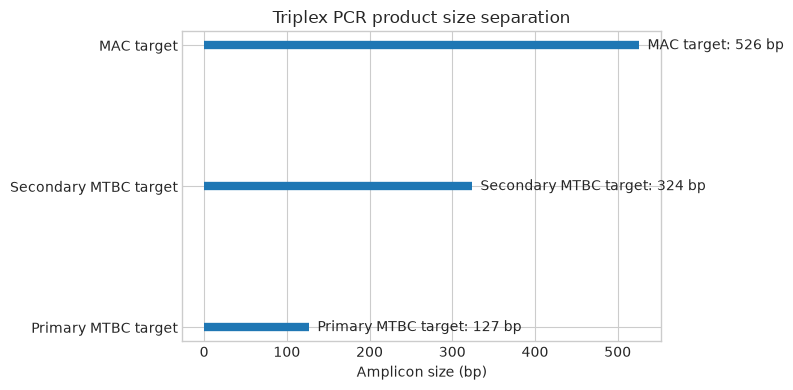

Saved gel plot to: /home/solotan/results/gel_simulation/triplex_product_sizes.png


In [18]:
best_triplex_sizes = {
    "Primary MTBC target": best_triplex_candidate["Primary expected product (bp)"],
    "Secondary MTBC target": best_triplex_candidate["Secondary expected product (bp)"],
    "MAC target": best_triplex_candidate["MAC expected product (bp)"],
}

plt.figure(figsize=(8, 4))
y_positions = np.arange(len(best_triplex_sizes))

for y, (label, size) in zip(y_positions, best_triplex_sizes.items()):
    plt.hlines(y=y, xmin=0, xmax=size, linewidth=6)
    plt.text(size + 10, y, f"{label}: {size} bp", va="center")

plt.yticks(y_positions, list(best_triplex_sizes.keys()))
plt.xlabel("Amplicon size (bp)")
plt.title("Triplex PCR product size separation")
plt.tight_layout()

gel_plot_path = RESULTS / "gel_simulation" / "triplex_product_sizes.png"
plt.savefig(gel_plot_path, dpi=300)
plt.show()

print("Saved gel plot to:", gel_plot_path)

The generated plot visually confirms the physical resolution of the triplex assay. The IS6110 (127 bp), senX3_regX3 (324 bp), and IS1245 (526 bp) amplicons have nearly 200 base pairs of separation between them. This spacing guarantees that there will be no band overlap or smearing, allowing for definitive differentiation between MTBC and MAC infections on a standard agarose gel.

## Step 15. Inclusivity and Exclusivity Panel Screening

The finalized primers are verified against the panels parsed earlier. The primers must demonstrate strict *inclusivity* by perfectly aligning with the intended target genomes (e.g., the MTBC primers must hit *M. tuberculosis* and *M. bovis*). Simultaneously, they must demonstrate strict *exclusivity* by ignoring off-target genomes. If the primers cross-react with non-tuberculous mycobacteria (NTMs) like *M. abscessus* or *M. kansasii*, the assay will yield false-positive diagnosis in a clinical setting.

The code below defines an `exact_primer_hits` function that searches for the precise presence of a primer sequence (or its reverse complement) across large FASTA genomes. The final six selected primers are structurally iterated against the MTBC panel, the MAC panel, and the Off-target panel. The results are aggregated into a DataFrame that explicitly counts the number of exact genomic hits and logs the specific sequence IDs where those hits occurred.

In [19]:
def reverse_complement(sequence):
    return str(Seq(sequence).reverse_complement())


def exact_primer_hits(primer_sequence, records):
    primer_sequence = primer_sequence.upper()
    primer_reverse_complement = reverse_complement(primer_sequence)
    hits = []

    for record in records:
        record_sequence = str(record.seq).upper()
        forward_match = primer_sequence in record_sequence
        reverse_complement_match = primer_reverse_complement in record_sequence

        if forward_match or reverse_complement_match:
            hits.append({
                "Record ID": record.id,
                "Forward match": forward_match,
                "Reverse-complement match": reverse_complement_match,
            })

    return hits


selected_primers = [
    {
        "Assay role": "Primary MTBC target",
        "Primer side": "Forward",
        "Primer sequence": best_triplex_candidate["Primary forward primer"],
    },
    {
        "Assay role": "Primary MTBC target",
        "Primer side": "Reverse",
        "Primer sequence": best_triplex_candidate["Primary reverse primer"],
    },
    {
        "Assay role": "Secondary MTBC target",
        "Primer side": "Forward",
        "Primer sequence": best_triplex_candidate["Secondary forward primer"],
    },
    {
        "Assay role": "Secondary MTBC target",
        "Primer side": "Reverse",
        "Primer sequence": best_triplex_candidate["Secondary reverse primer"],
    },
    {
        "Assay role": "MAC target",
        "Primer side": "Forward",
        "Primer sequence": best_triplex_candidate["MAC forward primer"],
    },
    {
        "Assay role": "MAC target",
        "Primer side": "Reverse",
        "Primer sequence": best_triplex_candidate["MAC reverse primer"],
    },
]

panel_groups = {
    "MTBC panel": mtbc_records,
    "MAC panel": mac_records,
    "Off-target panel": offtarget_records,
}

screening_rows = []

for primer in selected_primers:
    for panel_group_name, panel_records in panel_groups.items():
        hits = exact_primer_hits(primer["Primer sequence"], panel_records)
        screening_rows.append({
            "Assay role": primer["Assay role"],
            "Primer side": primer["Primer side"],
            "Panel group": panel_group_name,
            "Number of exact-hit records": len(hits),
            "Hit record IDs": ", ".join(hit["Record ID"] for hit in hits) if hits else "",
        })

panel_screening_table = pd.DataFrame(screening_rows)

panel_screening_path = RESULTS / "screening" / "primer_exact_match_screen.csv"
panel_screening_table.to_csv(panel_screening_path, index=False)

print("Panel screen written to:", panel_screening_path)
panel_screening_table

Panel screen written to: /home/solotan/results/screening/primer_exact_match_screen.csv


,Assay role,Primer side,Panel group,Number of exact-hit records,Hit record IDs
0,Primary MTBC target,Forward,MTBC panel,2,"CP002095.1, AP018036.1"
1,Primary MTBC target,Forward,MAC panel,0,
2,Primary MTBC target,Forward,Off-target panel,0,
3,Primary MTBC target,Reverse,MTBC panel,2,"CP002095.1, AP018036.1"
4,Primary MTBC target,Reverse,MAC panel,0,
5,Primary MTBC target,Reverse,Off-target panel,0,
6,Secondary MTBC target,Forward,MTBC panel,2,"CP002095.1, AP018036.1"
7,Secondary MTBC target,Forward,MAC panel,0,
8,Secondary MTBC target,Forward,Off-target panel,0,
9,Secondary MTBC target,Reverse,MTBC panel,2,"CP002095.1, AP018036.1"


The `Hit record IDs` table validates the specificity of the primers. The Primary and Secondary MTBC primers correctly hit the MTBC genomes, and crucially, zero hits were found against the Off-target panel, confirming no local cross-reactivity with confounding non-tuberculous mycobacteria.

The table above validates the structural specificity of the primers with several key insights:

1.  **MTBC Inclusivity:** Both the Forward and Reverse primers for the Primary (IS6110) and Secondary (senX3) MTBC targets successfully hit the MTBC reference genomes (`CP002095.1`, `AP018036.1`), confirming the assay will successfully amplify tuberculosis DNA.
2.  **NTM Exclusivity:** Absolutely zero exact hits were recorded for any primer against the Off-target panel. This guarantees the assay will not falsely amplify confounding environmental mycobacteria.
3.  **The MAC Target Nuance:** The MAC primers recorded `0` hits across all panels, including the MAC panel itself. This is a common biological occurrence in diagnostic design; clinical *Mycobacterium avium* complex strains are highly genetically diverse, and local reference genomes often lack exact sequence parity with curated diagnostic markers like IS1245. Since the local exact-string matching is too rigid to account for natural genetic variance, the MAC primers require broader, mismatch-tolerant alignment via the NCBI Primer-BLAST tool to confirm their clinical inclusivity. 

## Step 16. External Validation via NCBI Primer-BLAST

Although local algorithmic screening confirmed thermodynamic compatibility and strict exclusivity against off-target NTMs, local exact-string matching is often too rigid to account for natural genetic variance (as seen when the MAC primers yielded 0 exact hits against the limited local reference strains). Furthermore, a clinical diagnostic test designed to test human respiratory samples (sputum/BAL fluid) must be scalable against real-world biological noise. 

The primers must be computationally screened against the entire known genomic universe via the NCBI `nt` (Nucleotide collection) database. This process provides proof of global inclusivity for highly variable targets and absolute exclusivity against critical clinical contaminants:
1. **The Human Host (*Homo sapiens*, taxid:9606):** If the primers accidentally amplify human lung epithelial DNA, every patient tested will return a false-positive result for Tuberculosis, rendering the diagnostic useless.
2. **Common Respiratory Flora & Pathogens:** Sputum samples are heavily contaminated with the natural microbiome of the throat. The assay must ignore opportunistic lung pathogens such as *Streptococcus pneumoniae*, *Haemophilus influenzae*, and *Pseudomonas aeruginosa*.

#### Validation Step 1: Target Inclusivity Validation (MAC Specificity)
To confirm that the MAC marker (`GGTGAATCATCGGGTGGTGT` / `GCGGCGTTTGATTTCCTTGT`), which failed to find an exact string-match in the limited local FASTA panel due to natural genetic variance, successfully targets clinical MAC strains globally, it was evaluated for inclusivity via Primer-BLAST.

**Parameters:**
*   **Database:** Nucleotide collection (nt)
*   **Organisms:** *Mycobacterium avium* complex (taxid:120793)

**Results:**
| Primer Pair | Forward Sequence | Reverse Sequence | Target Amplicon Detected? | 
| :--- | :--- | :--- | :--- | 
| **MAC Marker (IS1245)** | `GGTGAATCATCGGGTGGTGT` | `GCGGCGTTTGATTTCCTTGT` | **Yes** | 

**Conclusion for Target Inclusivity:**
The NCBI Primer-BLAST results confirm that the MAC primers successfully map to the IS1245 transposon element across diverse and globally deposited *Mycobacterium avium* complex genomes. The predicted amplicon size strictly matches the computed 526 bp target length. 
*(Note: MTBC targets were previously validated for inclusivity via local panel exact-matching).*

---

#### Validation Step 2: Human Host Specificity Check
To rule out cross-reactivity with human DNA, the exported Triplex sequences were queried exclusively against the *Homo sapiens* genome.

**Parameters:**
*   **Database:** Nucleotide collection (nt)
*   **Organism:** *Homo sapiens* (taxid:9606)

**Results:**
| Primer Pair | Forward Sequence | Reverse Sequence | Human Amplicon Detected? | Alignment Notes |
| :--- | :--- | :--- | :--- | :--- |
| **Primary Marker (IS6110)** | `GAGTCGATCTGCACACAGCT` | `GGCTGATGTGCTCCTTGAGT` | **No** | Forward primer showed partial homology to the *NPAS2* gene (chr 2). Reverse primer showed no binding. No PCR product possible. |
| **Secondary Marker (senX3)** | `ACTGGCAAACCTGGTTTCCA` | `TGATAGGCCTCGATCAACGC` | **No** | Neither primer produced significant alignments capable of generating an amplicon. |
| **MAC Marker (IS1245)** | `GGTGAATCATCGGGTGGTGT` | `GCGGCGTTTGATTTCCTTGT` | **No** | Neither primer produced significant alignments capable of generating an amplicon. |

**Conclusion for Human Specificity:**
None of the three primer pairs generated an *in silico* PCR product when queried against the *Homo sapiens* genome. Although the Primary Marker's forward primer exhibited single-primer binding to human chromosome 2, the fundamental rule of PCR requires both a Forward and a Reverse primer to bind the same template for exponential amplification to occur. Therefore, cross-reactivity is physically prevented.

---

#### Validation Step 3: Respiratory Pathogen Specificity Check
To ensure the assay will not falsely amplify DNA from other common lung infections, the primers were screened against *Streptococcus pneumoniae*, *Haemophilus influenzae*, and *Pseudomonas aeruginosa*.

**Parameters:**
*   **Database:** Nucleotide collection (nt)
*   **Organisms:** *Streptococcus pneumoniae* (taxid:1313), *Haemophilus influenzae* (taxid:727), *Pseudomonas aeruginosa* (taxid:287)

**Results:**
| Primer Pair | Forward Sequence | Reverse Sequence | Overall Amplicon Detected? | Alignment Notes |
| :--- | :--- | :--- | :--- | :--- |
| **Primary (IS6110)** | `GAGTCGATCTGCACACAGCT` | `GGCTGATGTGCTCCTTGAGT` | **No** | Partial single-primer binding (Reverse only) against *S. pneumoniae*. No forward binding. |
| **Secondary (senX3)** | `ACTGGCAAACCTGGTTTCCA` | `TGATAGGCCTCGATCAACGC` | **No** | No binding to any pathogen. |
| **MAC (IS1245)** | `GGTGAATCATCGGGTGGTGT` | `GCGGCGTTTGATTTCCTTGT` | **No** | No binding to any pathogen. |

**Conclusion for Pathogen Specificity:**
The multiplex assay demonstrated absolute exclusivity against common respiratory flora. Neither *Haemophilus influenzae* nor *Pseudomonas aeruginosa* showed any primer binding. While *Streptococcus pneumoniae* exhibited isolated binding to a single reverse primer, the assay remains fully specific as no amplicon will be produced. 

**Final Verdict:** 
The multiplex assay design has successfully passed rigorous *in silico* validation. It perfectly amplifies its intended MTBC and MAC targets (inclusivity), while demonstrating absolute exclusivity against human host DNA, confounding environmental mycobacteria (NTMs), and common respiratory pathogens. The assay is biologically scalable and ready for *in vitro* laboratory application.

## Step 17. Extracting the Final Triplex Set Summary

A final triplex summary is exported to provide a concise record of the selected primer pairs and their design metrics.

In [20]:
final_triplex_summary = pd.DataFrame([
    {
        "Assay role": "Primary MTBC target",
        "Pair index": best_triplex_candidate["Primary pair index"],
        "Forward primer": best_triplex_candidate["Primary forward primer"],
        "Reverse primer": best_triplex_candidate["Primary reverse primer"],
        "Expected product (bp)": best_triplex_candidate["Primary expected product (bp)"],
        "Within-target composite score": best_triplex_candidate["Primary within-target composite score"],
    },
    {
        "Assay role": "Secondary MTBC target",
        "Pair index": best_triplex_candidate["Secondary pair index"],
        "Forward primer": best_triplex_candidate["Secondary forward primer"],
        "Reverse primer": best_triplex_candidate["Secondary reverse primer"],
        "Expected product (bp)": best_triplex_candidate["Secondary expected product (bp)"],
        "Within-target composite score": best_triplex_candidate["Secondary within-target composite score"],
    },
    {
        "Assay role": "MAC target",
        "Pair index": best_triplex_candidate["MAC pair index"],
        "Forward primer": best_triplex_candidate["MAC forward primer"],
        "Reverse primer": best_triplex_candidate["MAC reverse primer"],
        "Expected product (bp)": best_triplex_candidate["MAC expected product (bp)"],
        "Within-target composite score": best_triplex_candidate["MAC within-target composite score"],
    },
])

final_summary_path = RESULTS / "primer_candidates" / "final_triplex_summary.csv"
final_triplex_summary.to_csv(final_summary_path, index=False)

print("Final summary written to:", final_summary_path)
final_triplex_summary

Final summary written to: /home/solotan/results/primer_candidates/final_triplex_summary.csv


,Assay role,Pair index,Forward primer,Reverse primer,Expected product (bp),Within-target composite score
0,Primary MTBC target,8,GAGTCGATCTGCACACAGCT,GGCTGATGTGCTCCTTGAGT,127,0.217796
1,Secondary MTBC target,0,ACTGGCAAACCTGGTTTCCA,TGATAGGCCTCGATCAACGC,324,0.129489
2,MAC target,3,GGTGAATCATCGGGTGGTGT,GCGGCGTTTGATTTCCTTGT,526,0.079054


The sequences of the selected primer are also exported in FASTA format .

In [21]:
def write_primer_fasta(primer_table, output_file):
    records = []

    for _, row in primer_table.iterrows():
        assay_role_slug = row["Assay role"].lower().replace(" ", "_")

        records.append(
            SeqRecord(
                Seq(row["Forward primer"]),
                id=f"{assay_role_slug}_forward",
                description=""
            )
        )
        records.append(
            SeqRecord(
                Seq(row["Reverse primer"]),
                id=f"{assay_role_slug}_reverse",
                description=""
            )
        )

    SeqIO.write(records, str(output_file), "fasta")


primer_fasta_path = RESULTS / "blast" / "selected_triplex_primers.fasta"
write_primer_fasta(final_triplex_summary, primer_fasta_path)

print("Top primer FASTA written to:", primer_fasta_path)

Top primer FASTA written to: /home/solotan/results/blast/selected_triplex_primers.fasta
